Building ML Model

In [3]:
import numpy as np 
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, LearningCurveDisplay
from sklearn.metrics import r2_score, mean_squared_error
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

df = pd.read_csv("satellite_collision_dataset.csv")
#Feature Engineering
df['speed_distance_ratio'] = df['relative_speed_km_s'] / (df['distance_km'] + 0.001)
df['distance_squared'] = df['distance_km'] ** 2
df['inverse_distance'] = 1 / (df['distance_km'] + 0.001)
df['speed_times_risk'] = df['relative_speed_km_s'] * df['object_type_risk']
df['distance_times_risk'] = df['distance_km'] * df['object_type_risk']
df['time_to_collision'] = df['distance_km'] / (df['relative_speed_km_s'] + 0.001)
df['collision_urgency'] = df['object_type_risk'] / (df['distance_km'] + 1)
df['relative_energy'] = df['relative_speed_km_s'] ** 2  # Proportional to kinetic energy

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# Plot 1: Correlation heatmap: Check for strong features
corr = df.corr(numeric_only=True)
sns.heatmap(corr, cmap='coolwarm', ax=axes[0, 0], linewidths=1)
axes[0, 0].set_title('Feature Correlation')

# Plot 2: Distance vs Probability
axes[0, 1].scatter(df['distance_km'], df['collision_probability'], alpha=0.5, s=10)
axes[0, 1].set_xlabel("Distance (km)")
axes[0, 1].set_ylabel("Collision Probability")
axes[0, 1].set_title("Distance vs Probability")

# Plot 3: Speed vs Probability
axes[1, 0].scatter(df['relative_speed_km_s'], df['collision_probability'], alpha=0.5, s=10)
axes[1, 0].set_xlabel("Relative Speed (km/s)")
axes[1, 0].set_ylabel("Collision Probability")
axes[1, 0].set_title("Speed vs Probability")

axes[1,1].set_axis_off()

plt.tight_layout()
plt.savefig('data_analysis.png', dpi=150)
plt.close()
target_corr = df.corr(numeric_only=True)['collision_probability'].abs().sort_values(ascending=False)
top_features = target_corr[1:11].index.tolist() 
X = df[top_features] #use top features from the corr matrix
y = df['collision_probability']

# Split and scale data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#Build Neural Network
model_nn = Sequential([
    Dense(64, input_dim=X_train_scaled.shape[1], activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    Dropout(0.2),
    
    Dense(32, activation='relu'),
    Dense(1)
])

model_nn.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae', 'mse']
)

# Add early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True
)

history = model_nn.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
)
#Extract Training metrics for eval
loss = history.history['loss']
val_loss = history.history['val_loss']

Epoch 1/50
100/100 [==============================] - 4s 12ms/step - loss: 0.2791 - mae: 0.3992 - mse: 0.2791 - val_loss: 0.3542 - val_mae: 0.5628 - val_mse: 0.3542
Epoch 2/50
100/100 [==============================] - 1s 7ms/step - loss: 0.1129 - mae: 0.2607 - mse: 0.1129 - val_loss: 0.1568 - val_mae: 0.3675 - val_mse: 0.1568
Epoch 3/50
100/100 [==============================] - 1s 7ms/step - loss: 0.0727 - mae: 0.2098 - mse: 0.0727 - val_loss: 0.0854 - val_mae: 0.2698 - val_mse: 0.0854
Epoch 4/50
100/100 [==============================] - 1s 10ms/step - loss: 0.0565 - mae: 0.1865 - mse: 0.0565 - val_loss: 0.0461 - val_mae: 0.1928 - val_mse: 0.0461
Epoch 5/50
100/100 [==============================] - 1s 8ms/step - loss: 0.0442 - mae: 0.1656 - mse: 0.0442 - val_loss: 0.0436 - val_mae: 0.1899 - val_mse: 0.0436
Epoch 6/50
100/100 [==============================] - 2s 16ms/step - loss: 0.0364 - mae: 0.1491 - mse: 0.0364 - val_loss: 0.0280 - val_mae: 0.1529 - val_mse: 0.0280
Epoch 7/50
10

Testing and evaluating the ML model

32/32 [==============================] - 1s 8ms/step
Collision Probability: [0.34007496]
ACTION: DANGER!!!!, Execute Manuever
MODEL EVALUATION REPORT: 
R2 Score: 0.95
Mean Squared Error: 0.00329
Root Mean Squared Error: 0.0574


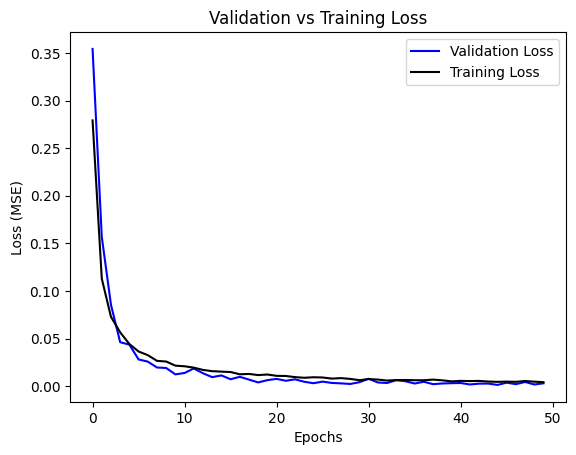

INFO:tensorflow:Assets written to: ram://f1328b07-cfc6-40ac-b3aa-3ed4e50665aa/assets
Saving ML model to computer.....
ML Model saved.


In [4]:
import joblib

preds = model_nn.predict(X_test_scaled)
#build avoidance system
def classify_probability(prob):
    if prob < 0.001: #<0.1%
        return "STATUS: SAFE, No action needed"
    elif prob < 0.01: #<1%
        return "KEEP ON GUARD"
    elif prob < 0.1: #<10%
        return "WARNING!!!, Plan Manuever"
    elif prob < 0.5: #<50%
        return "DANGER!!!!, Execute Manuever"
    else: #>50%
        return "CRITICAL!!!, Emergency evasion"

print('='*50)
print(f"Collision Probability: {(preds[0])}")
print(f"ACTION: {classify_probability(preds[0])}")
print('='*50)

#Evaluate Model
r2 = r2_score(y_test, preds) #R2 score
mse = mean_squared_error(y_test, preds) #MSE
rmse = np.sqrt(mse) #RMSE

#Present Evals
print('='*50)
print("MODEL EVALUATION REPORT: ")
print(f"R2 Score: {round(r2, 2)}")
print(f"Mean Squared Error: {round(mse, 5)}")
print(f"Root Mean Squared Error: {round(rmse, 5)}")
print('='*50)

#Visualize Evals:
epochs = 50
epoch_range = range(epochs)
#Plot: Training Loss vs Validation Loss
plt.plot(epoch_range, val_loss, color='blue', label='Validation Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Validation vs Training Loss")
plt.plot(epoch_range, loss, color='black', label='Training Loss')
plt.legend()
plt.show()
#save model to computer
joblib.dump(model_nn, 'Satellite_model.pkl')
print("Saving ML model to computer.....")
print("ML Model saved.") 
